# VNL Men 2023: Interpretable Player Clustering

This notebook runs the clustering pipeline and explains *why* each cluster gets its archetype label.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from vnl_men_2023.player_clustering import load_player_data, run_clustering

sns.set_theme(style='whitegrid')

In [2]:
data_path = PROJECT_ROOT / 'data' / 'raw' / 'VNL2023.csv'
df = load_player_data(str(data_path))
result = run_clustering(df)

print(f'Rows: {len(df)}')
print(f'Selected k: {result.best_k}')
print(f'Silhouette @ selected k: {result.silhouette:.4f}')

Rows: 131
Selected k: 4
Silhouette @ selected k: 0.4105


## 1) How was K chosen?

The pipeline tests k=2-8 and selects the k with the highest silhouette score.

In [3]:
result.silhouette_by_k

,k,silhouette
0,2,0.359372
1,3,0.326694
2,4,0.410532
3,5,0.389774
4,6,0.371209
5,7,0.368425
6,8,0.366220


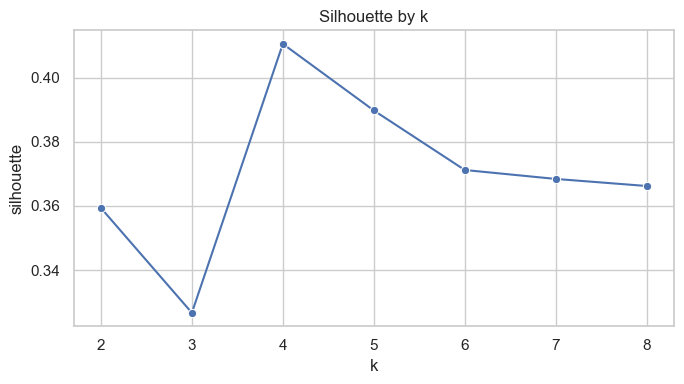

In [4]:
plt.figure(figsize=(7, 4))
sns.lineplot(data=result.silhouette_by_k, x='k', y='silhouette', marker='o')
plt.title('Silhouette by k')
plt.tight_layout()
plt.show()

## 2) What makes each cluster different?

Raw means show actual stat levels; z-scores show relative strength vs overall player population.

In [5]:
display(result.cluster_profile_raw)
display(result.cluster_profile_z)

,Attack,Block,Serve,Set,Dig,Receive
cluster_id,,,,,,
0,0.562,0.026,0.013,0.000,7.053,3.999
1,10.729,0.963,1.019,0.026,4.196,3.212
2,5.400,1.076,0.454,0.004,1.856,0.594
3,0.536,0.558,0.321,17.879,3.943,0.011


,Attack,Block,Serve,Set,Dig,Receive
cluster_id,,,,,,
0,-1.198,-1.174,-1.155,-0.365,1.751,1.168
1,1.200,0.168,1.068,-0.361,0.371,0.771
2,-0.057,0.330,-0.181,-0.364,-0.760,-0.550
3,-1.204,-0.412,-0.475,2.611,0.249,-0.844


## 3) Why each label was assigned

These are rule-based explanations from the label assignment function.

In [6]:
result.cluster_label_rationale

,cluster_id,cluster_label,rule_reason
0,0,Defensive Specialists,High defensive z-score and low offense.
1,1,Offensive Specialists,High Attack+Serve combined z-score (>= 1.5).
2,2,Balanced All-Around,No specialist threshold hit; treated as balanc...
3,3,Setting Specialists,High Set z-score (>= 1.0).


## 4) Cluster visualization (PCA)

PCA is only a 2D projection for visualization. Cluster assignment itself is done in the full standardized feature space.

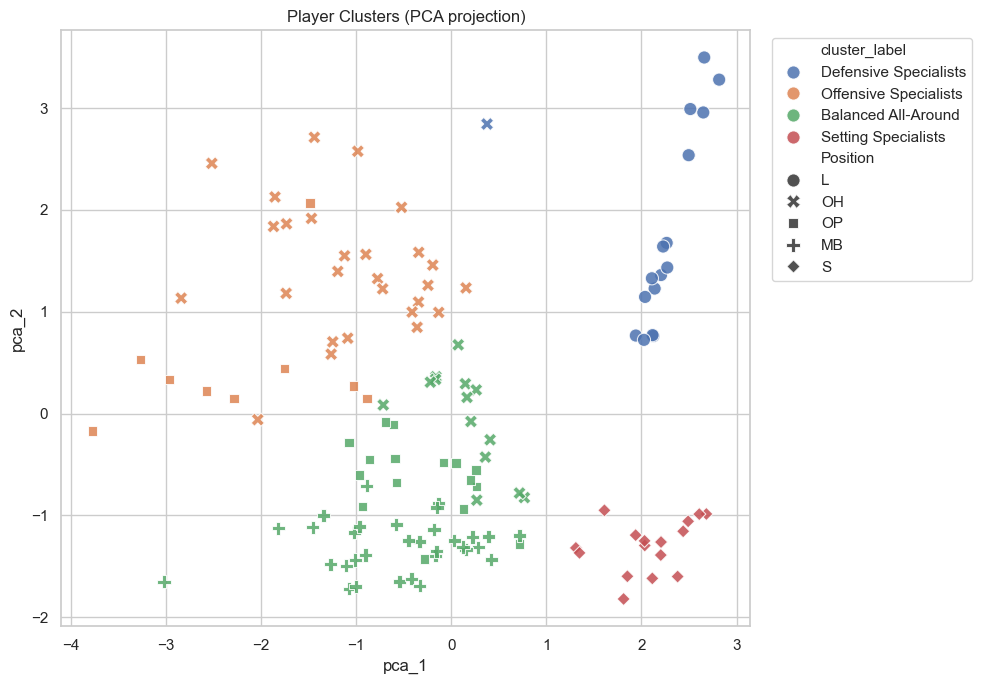

In [7]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=result.players,
    x='pca_1',
    y='pca_2',
    hue='cluster_label',
    style='Position',
    s=90,
    alpha=0.85
)
plt.title('Player Clusters (PCA projection)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [8]:
cluster_counts = (
    result.players.groupby(['cluster_id', 'cluster_label'], as_index=False)
    .size()
    .rename(columns={'size': 'players'})
    .sort_values('cluster_id')
)
cluster_counts

,cluster_id,cluster_label,players
0,0,Defensive Specialists,17
1,1,Offensive Specialists,36
2,2,Balanced All-Around,62
3,3,Setting Specialists,16


## Optional: Save outputs

Use the script for the full export set:
- `make cluster`
- `make cluster-tsne`